# Time Series Basics
author: Louis Richard\
How time series are represented in pyrfu, how to convert between the
different time formats, and how to clip, resample, evaluate and concatenate
time series. Uses synthetic data only, so no data download is needed.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from pyrfu import pyrf
from pyrfu.plot import plot_line, use_pyrfu_style

use_pyrfu_style(usetex=True)

Load IGRF coefficients ...


## Time formats
### Time intervals
Time intervals are given as a list of two ISO 8601 strings. They can be
extended by a number of seconds on each side, e.g., to load a bit more data
than needed before filtering.

In [2]:
tint = ["2019-09-14T07:54:00.000", "2019-09-14T07:54:20.000"]
tint_long = pyrf.extend_tint(tint, [-5, 5])
tint_long

[np.str_('2019-09-14T07:53:55.000000000'),
 np.str_('2019-09-14T07:54:25.000000000')]

### Conversions
Internally, times are `numpy.datetime64` in ns units. pyrfu provides
conversions to and from ISO 8601 strings, unix time (seconds since
1970-01-01, without leap seconds) and CDF epochs.

In [3]:
tint_dt64 = pyrf.iso86012datetime64(np.array(tint))
tint_unix = pyrf.datetime642unix(tint_dt64)
tint_tt2000 = pyrf.datetime642ttns(tint_dt64)

print("datetime64 :", tint_dt64)
print("unix       :", tint_unix.tolist())
print("TT2000     :", tint_tt2000)

datetime64 : ['2019-09-14T07:54:00.000000000' '2019-09-14T07:54:20.000000000']
unix       : [1568447640.0, 1568447660.0]
TT2000     : [621719709184000000 621719729184000000]


And back. The CDF epoch type is inferred from the data type: integers are
CDF_TT2000 (ns since J2000, with leap seconds), floats are CDF_EPOCH and
complex numbers are CDF_EPOCH16.

In [4]:
print(pyrf.unix2datetime64(tint_unix))
print(pyrf.ttns2datetime64(tint_tt2000))
print(pyrf.cdfepoch2datetime64(tint_tt2000))
print(pyrf.datetime642iso8601(tint_dt64))

['2019-09-14T07:54:00.000000000' '2019-09-14T07:54:20.000000000']
['2019-09-14T07:54:00.000000000' '2019-09-14T07:54:20.000000000']
['2019-09-14T07:54:00.000000000' '2019-09-14T07:54:20.000000000']
['2019-09-14T07:54:00.000000000' '2019-09-14T07:54:20.000000000']


TT2000 is in Terrestrial Time, which is ahead of UTC by 32.184 s plus the
leap seconds (37 s since 2017), while unix time ignores leap seconds. This is
handled by the conversions, but matters when computing time differences from
raw TT2000 values.

In [5]:
j2000_unix = pyrf.datetime642unix(
    np.array(["2000-01-01T12:00:00"], dtype="datetime64[ns]")
)
dt_leap = tint_tt2000 * 1e-9 - (tint_unix - j2000_unix)
print(f"TT2000 - (unix - J2000) = {dt_leap[0]:.3f} s")

TT2000 - (unix - J2000) = 69.184 s


## Create time series
Time series are `xarray.DataArray` with a `time` coordinate. The
constructors `ts_scalar`, `ts_vec_xyz` and `ts_tensor_xyz` create scalar,
vector and 2nd order tensor time series, with the component coordinates
(`comp`, or `rcomp` and `ccomp`) and the `TENSOR_ORDER` attribute used by
the rest of pyrfu.

As an example, build a 128 Hz magnetic field with a background
$B_0 = 20$ nT along $z$ and a circularly polarized wave at 2 Hz, a density
and an isotropic pressure tensor.

In [6]:
f_s = 128.0
n_t = int(np.diff(tint_unix)[0] * f_s)
time = tint_dt64[0] + (np.arange(n_t) / f_s * 1e9).astype("timedelta64[ns]")
t_sec = np.arange(n_t) / f_s

rng = np.random.default_rng(42)

b_data = np.zeros((n_t, 3))
b_data[:, 0] = 2.0 * np.cos(2 * np.pi * 2.0 * t_sec)
b_data[:, 1] = 2.0 * np.sin(2 * np.pi * 2.0 * t_sec)
b_data[:, 2] = 20.0
b_data += 0.3 * rng.standard_normal((n_t, 3))
b_xyz = pyrf.ts_vec_xyz(time, b_data, {"UNITS": "nT"})

n_data = 10.0 + 0.5 * np.sin(2 * np.pi * 0.1 * t_sec)
n_i = pyrf.ts_scalar(time, n_data, {"UNITS": "cm^-3"})

p_data = np.tile(np.eye(3), (n_t, 1, 1)) * n_data[:, None, None] * 0.16
p_xyz = pyrf.ts_tensor_xyz(time, p_data, {"UNITS": "nPa"})

b_xyz

<xarray.DataArray (time: 2560, comp: 3)> Size: 61kB
array([[ 2.09141512, -0.31199523, 20.22513536],
       [ 2.27253887, -0.38927628, 19.60934615],
       [ 1.99992268,  0.29530787, 19.99495965],
       ...,
       [ 2.28403341, -0.26974597, 19.81830807],
       [ 1.96956081, -0.77494403, 19.93851732],
       [ 1.80251234, -0.31690007, 19.77503149]], shape=(2560, 3))
Coordinates:
  * time     (time) datetime64[ns] 20kB 2019-09-14T07:54:00 ... 2019-09-14T07...
  * comp     (comp) <U1 12B 'x' 'y' 'z'
Attributes:
    UNITS:         nT
    TENSOR_ORDER:  1

The usual vector operations act on time series and keep the time axis.

In [7]:
b_mag = pyrf.norm(b_xyz)
b_hat = pyrf.normalize(b_xyz)
b_perp = pyrf.cross(b_hat, pyrf.cross(b_xyz, b_hat))
p_scal = pyrf.trace(p_xyz) / 3

print(f"<|B|> = {b_mag.mean().data:.2f} nT")
print(f"<B.b> = {pyrf.dot(b_xyz, b_hat).mean().data:.2f} nT")
print(f"<p>   = {p_scal.mean().data:.2f} nPa")

<|B|> = 20.09 nT
<B.b> = 20.09 nT
<p>   = 1.60 nPa


The sampling frequency and the time limits of a time series are given by
`calc_fs`, `start` and `end` (in unix time).

In [8]:
print(f"f_s = {pyrf.calc_fs(b_xyz):.1f} Hz")
print(pyrf.unix2datetime64(np.array([pyrf.start(b_xyz), pyrf.end(b_xyz)])))

f_s = 128.0 Hz
['2019-09-14T07:54:00.000000000' '2019-09-14T07:54:19.992187392']


## Select a time interval
`time_clip` keeps the samples in $[t_{start}, t_{stop}]$ (inclusive). The
time interval can be a list of ISO 8601 strings, an array of datetime64 or
another time series (whose first and last times are used).

In [9]:
tint_zoom = ["2019-09-14T07:54:05.000", "2019-09-14T07:54:07.000"]
b_zoom = pyrf.time_clip(b_xyz, tint_zoom)
n_zoom = pyrf.time_clip(n_i, b_zoom)

print(b_zoom.time.data[[0, -1]], len(b_zoom))
print(n_zoom.time.data[[0, -1]], len(n_zoom))

['2019-09-14T07:54:05.000000000' '2019-09-14T07:54:07.000000000'] 257
['2019-09-14T07:54:05.000000000' '2019-09-14T07:54:07.000000000'] 257


## Resample
`resample` brings a time series onto the time line of a reference time
series. If the input is sampled more than twice as fast as the reference it
is averaged in windows of length $1/f_s$ around the reference times,
otherwise it is interpolated. An interpolation method can be forced with
`method`.

Here, the 2 Hz wave is averaged out when resampling to 1 Hz, while forcing
the interpolation picks one point per second, which aliases the wave into a
spurious constant $B_x \approx 2$ nT.

In [10]:
time_1hz = tint_dt64[0] + (np.arange(int(n_t / f_s)) * 1e9).astype("timedelta64[ns]")
ref_1hz = pyrf.ts_scalar(time_1hz, np.zeros(len(time_1hz)))

b_avg_1hz = pyrf.resample(b_xyz, ref_1hz)
b_int_1hz = pyrf.resample(b_xyz, ref_1hz, method="linear")

print(f"f_s = {pyrf.calc_fs(b_avg_1hz):.1f} Hz")
print(f"<Bx>, averaged     : {b_avg_1hz[:, 0].mean().data:.2f} nT")
print(f"<Bx>, interpolated : {b_int_1hz[:, 0].mean().data:.2f} nT")

f_s = 1.0 Hz
<Bx>, averaged     : 0.01 nT
<Bx>, interpolated : 1.98 nT


Resampling onto a faster time line interpolates. Interpolation extrapolates
linearly outside the time range of the input, so clip the reference first
if this is not wanted.

In [11]:
n_i_slow = pyrf.resample(n_i, ref_1hz)
n_i_fast = pyrf.resample(n_i_slow, b_xyz)
n_i_fast

<xarray.DataArray (time: 2560)> Size: 20kB
array([10.07788595, 10.07954354, 10.08120114, ...,  9.88695926,
        9.88835977,  9.88976029], shape=(2560,))
Coordinates:
  * time     (time) datetime64[ns] 20kB 2019-09-14T07:54:00 ... 2019-09-14T07...
Attributes:
    UNITS:         cm^-3
    TENSOR_ORDER:  0

## Evaluate at given times
`t_eval` picks, for each target time, the first sample at or after it,
without interpolation. It is useful for, e.g., the value of a slowly
varying quantity at the times of a few events.

In [12]:
t_events = pyrf.iso86012datetime64(
    np.array(["2019-09-14T07:54:03.0021", "2019-09-14T07:54:12.5000"]),
)
pyrf.t_eval(b_xyz, t_events)

<xarray.DataArray (time: 2, comp: 3)> Size: 48B
array([[ 2.02355339,  0.19643623, 20.44188607],
       [ 2.00757885,  0.1628029 , 19.9956998 ]])
Coordinates:
  * time     (time) datetime64[ns] 16B 2019-09-14T07:54:03.002100 2019-09-14T...
  * comp     (comp) <U1 12B 'x' 'y' 'z'

## Concatenate time series
`ts_append` concatenates two time series along the time axis (the first
input must be earlier than the second), e.g., two consecutive files.

In [13]:
b_part1 = pyrf.time_clip(b_xyz, [tint[0], "2019-09-14T07:54:10.000"])
b_part2 = pyrf.time_clip(b_xyz, ["2019-09-14T07:54:10.005", tint[1]])
b_joined = pyrf.ts_append(b_part1, b_part2)

print(len(b_part1), len(b_part2), len(b_joined), len(b_xyz))
print(np.array_equal(b_joined.data, b_xyz.data))

1281 1279 2560 2560
True


## Plot

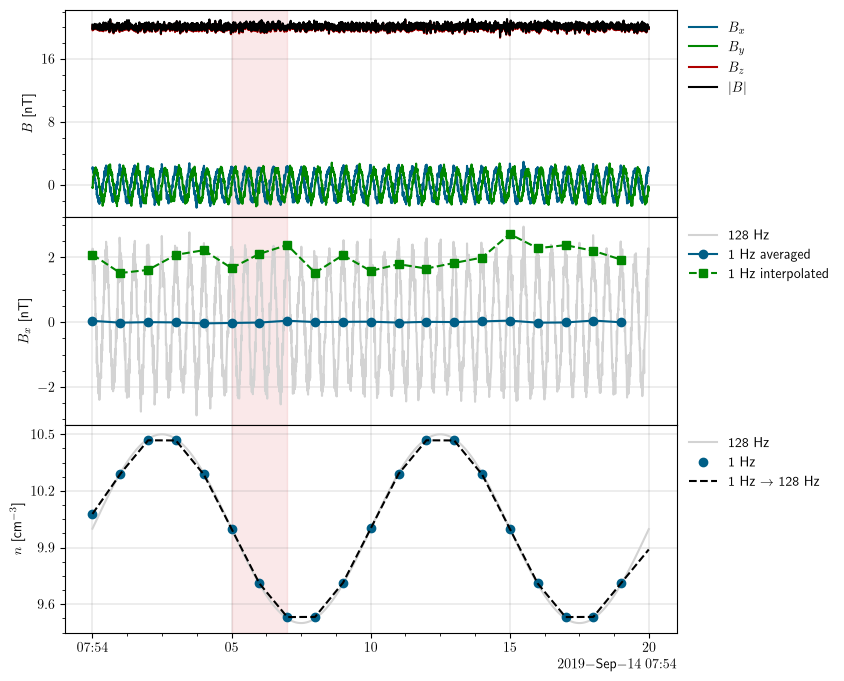

In [14]:
f, axs = plt.subplots(3, sharex="all", figsize=(9, 7))
f.subplots_adjust(hspace=0, left=0.1, right=0.78, top=0.97, bottom=0.08)
legend_opts = {"loc": "upper left", "bbox_to_anchor": (1.0, 1.0), "frameon": False}

plot_line(axs[0], b_xyz)
plot_line(axs[0], b_mag, color="k")
axs[0].set_ylabel("$B$ [nT]")
axs[0].legend(["$B_x$", "$B_y$", "$B_z$", "$|B|$"], **legend_opts)

plot_line(axs[1], b_xyz[:, 0], color="lightgray")
plot_line(axs[1], b_avg_1hz[:, 0], marker="o", linestyle="-")
plot_line(axs[1], b_int_1hz[:, 0], marker="s", linestyle="--")
axs[1].set_ylabel("$B_x$ [nT]")
axs[1].legend(["128 Hz", "1 Hz averaged", "1 Hz interpolated"], **legend_opts)

plot_line(axs[2], n_i, color="lightgray")
plot_line(axs[2], n_i_slow, marker="o", linestyle="")
plot_line(axs[2], n_i_fast, color="k", linestyle="--")
axs[2].set_ylabel("$n$ [cm$^{-3}$]")
axs[2].legend(["128 Hz", "1 Hz", "1 Hz $\\rightarrow$ 128 Hz"], **legend_opts)

# Highlight the clipped time interval
for ax in axs:
    ax.axvspan(*b_zoom.time.data[[0, -1]], color="tab:red", alpha=0.1)